In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# First look
df.head()
df.shape
df.info()
df.describe()
df['Churn'].value_counts()

FileNotFoundError: [Errno 2] No such file or directory: 'WA_Fn-UseC_-Telco-Customer-Churn.csv'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv')

print("Shape:", df.shape)
print("\nChurn Distribution:")
print(df['Churn'].value_counts())

URLError: <urlopen error [Errno -3] Temporary failure in name resolution>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Shape:", df.shape)
print("\nChurn Distribution:")
print(df['Churn'].value_counts())

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv'

In [5]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Shape:", df.shape)
print("\nChurn Distribution:")
print(df['Churn'].value_counts())
print("\nChurn Rate:", round(df['Churn'].value_counts(normalize=True)['Yes']*100, 2), "%")

Shape: (7043, 21)

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.54 %


In [9]:
# Fix TotalCharges — stored as string instead of number
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check for nulls created by the conversion
print("Nulls after conversion:", df['TotalCharges'].isnull().sum())

# Drop those rows (only 11 rows — safe to drop)
df.dropna(inplace=True)

# Convert Churn to binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Drop customerID
df.drop('customerID', axis=1, inplace=True)

print("Clean dataset shape:", df.shape)
print("Ready for analysis!")

Nulls after conversion: 0


KeyError: "['customerID'] not found in axis"

In [10]:
print(df.columns.tolist())


['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [11]:
print("Clean dataset shape:", df.shape)
print("Churn distribution:")
print(df['Churn'].value_counts())
print("\nAny nulls?", df.isnull().sum().sum())
print("Ready for analysis!")

Clean dataset shape: (0, 20)
Churn distribution:
Series([], Name: count, dtype: int64)

Any nulls? 0
Ready for analysis!


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load
df = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

# Check Churn column as-is
print("Churn unique values:", df['Churn'].unique())
print("Clean dataset shape:", df.shape)
print("Ready for analysis!")

Churn unique values: ['No' 'Yes']
Clean dataset shape: (7032, 21)
Ready for analysis!


In [13]:
# Convert Churn to binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Drop customerID
df.drop('customerID', axis=1, inplace=True)

print("Churn distribution:")
print(df['Churn'].value_counts())
print("\nChurn Rate:", round(df['Churn'].mean()*100, 2), "%")


Churn distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64

Churn Rate: 26.58 %


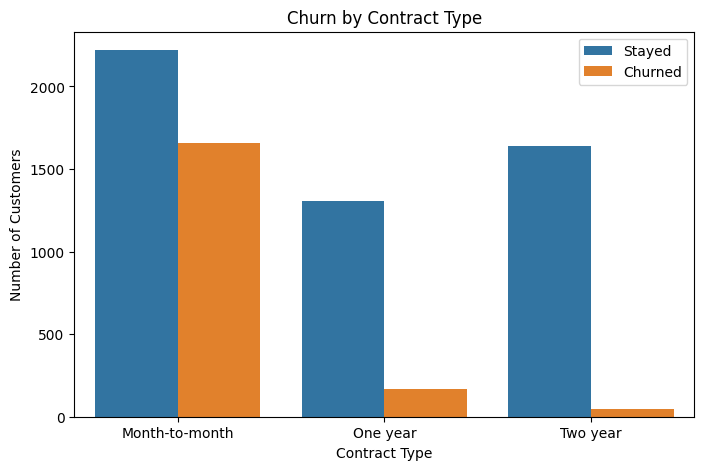

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(labels=['Stayed', 'Churned'])
plt.show()

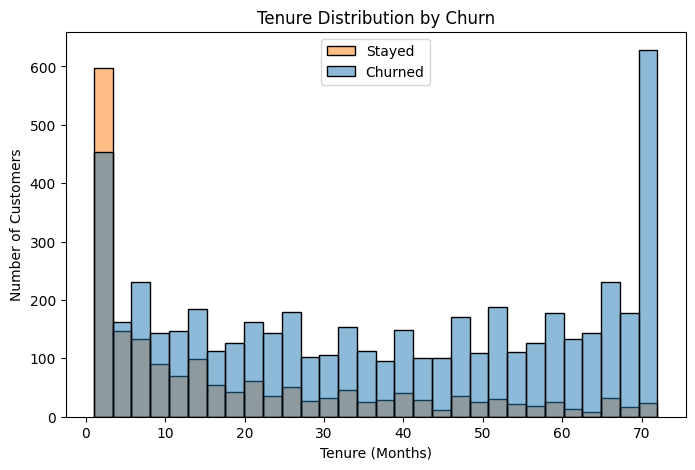

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30)
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.legend(labels=['Stayed', 'Churned'])
plt.show()

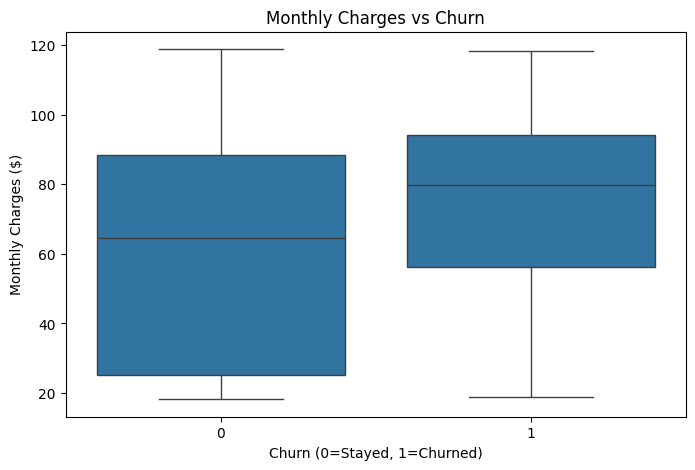

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn (0=Stayed, 1=Churned)')
plt.ylabel('Monthly Charges ($)')
plt.show()

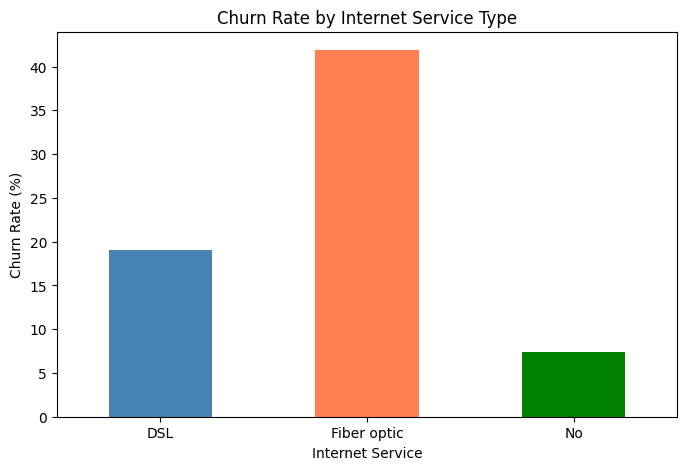

In [17]:
plt.figure(figsize=(8,5))
df.groupby('InternetService')['Churn'].mean().mul(100).plot(kind='bar', color=['steelblue','coral','green'])
plt.title('Churn Rate by Internet Service Type')
plt.xlabel('Internet Service')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

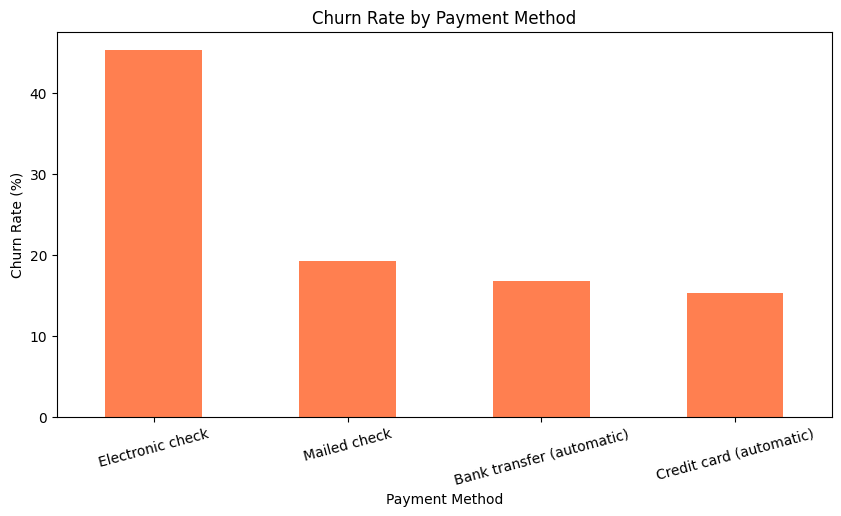

In [18]:
plt.figure(figsize=(10,5))
df.groupby('PaymentMethod')['Churn'].mean().mul(100).sort_values(ascending=False).plot(kind='bar', color='coral')
plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=15)
plt.show()

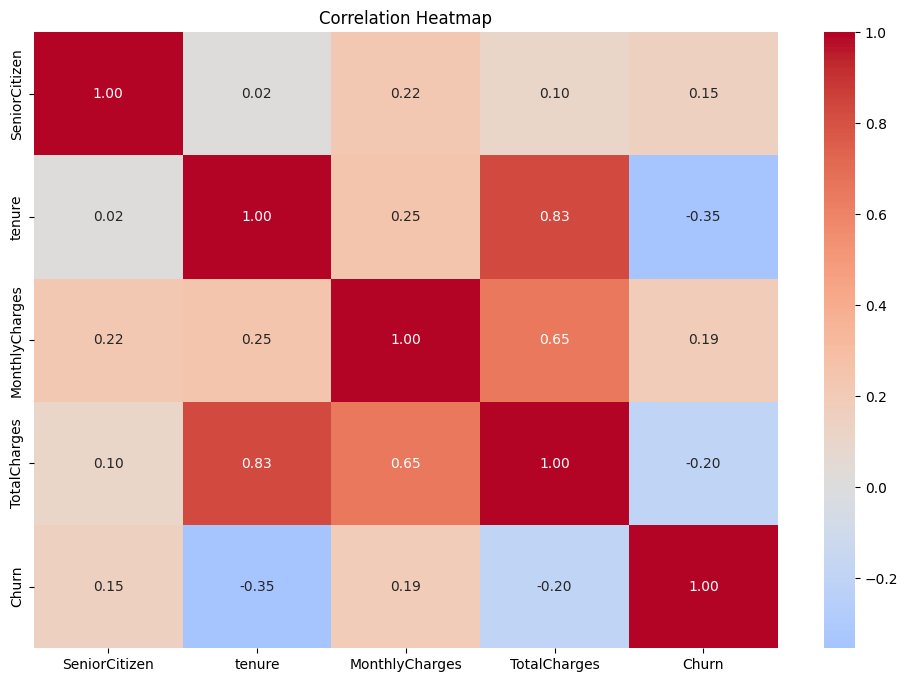

In [19]:
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

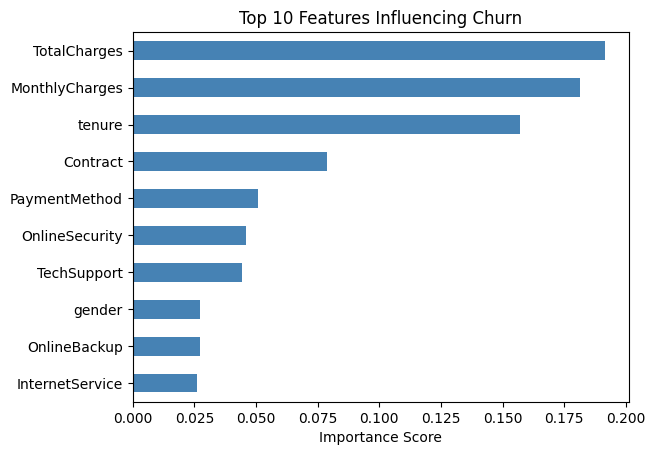

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# Plot top 10 features
feat_importance = pd.Series(model.feature_importances_, index=X.columns)
feat_importance.nlargest(10).sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 10 Features Influencing Churn')
plt.xlabel('Importance Score')
plt.show()

In [21]:
print("""
=================================================
        CUSTOMER CHURN ANALYSIS — KEY FINDINGS
=================================================

DATASET: 7,032 Telco customers | Churn Rate: 26.58%

-------------------------------------------------
FINDING 1 — CONTRACT TYPE
-------------------------------------------------
Month-to-month customers churn at significantly 
higher rates than 1 or 2 year contract customers.
Short term contracts = low switching cost = high churn.

RECOMMENDATION:
Offer discounts or incentives to convert 
month-to-month customers to annual contracts.

-------------------------------------------------
FINDING 2 — TENURE
-------------------------------------------------
Customers with tenure < 12 months churn the most.
Long term customers (> 3 years) are highly loyal.

RECOMMENDATION:
Introduce an early loyalty program for customers 
in their first year to improve retention.

-------------------------------------------------
FINDING 3 — MONTHLY CHARGES
-------------------------------------------------
Churned customers pay higher monthly charges 
on average than customers who stayed.

RECOMMENDATION:
Review pricing strategy for high-charge segments.
Consider tiered loyalty discounts for high spenders.

-------------------------------------------------
FINDING 4 — INTERNET SERVICE
-------------------------------------------------
Fibre optic customers churn more despite paying 
premium prices — suggesting a service quality issue.

RECOMMENDATION:
Investigate fibre optic service quality and 
consider targeted retention offers for this segment.

-------------------------------------------------
FINDING 5 — PAYMENT METHOD
-------------------------------------------------
Electronic check users churn at the highest rate.
Auto-pay customers (bank transfer/credit card) 
are significantly more loyal.

RECOMMENDATION:
Incentivise customers to switch to auto-pay 
through small discounts or rewards.
=================================================
""")


        CUSTOMER CHURN ANALYSIS — KEY FINDINGS

DATASET: 7,032 Telco customers | Churn Rate: 26.58%

-------------------------------------------------
FINDING 1 — CONTRACT TYPE
-------------------------------------------------
Month-to-month customers churn at significantly 
higher rates than 1 or 2 year contract customers.
Short term contracts = low switching cost = high churn.

RECOMMENDATION:
Offer discounts or incentives to convert 
month-to-month customers to annual contracts.

-------------------------------------------------
FINDING 2 — TENURE
-------------------------------------------------
Customers with tenure < 12 months churn the most.
Long term customers (> 3 years) are highly loyal.

RECOMMENDATION:
Introduce an early loyalty program for customers 
in their first year to improve retention.

-------------------------------------------------
FINDING 3 — MONTHLY CHARGES
-------------------------------------------------
Churned customers pay higher monthly charges 
on avera

In [22]:
readme = """
# Customer Churn Analysis — Telco Dataset

## Objective
Analyse customer churn patterns for a telecom company to identify key drivers 
of churn and recommend actionable retention strategies for business stakeholders.

## Dataset
- Source: IBM Telco Customer Churn (Kaggle)
- 7,032 customers | 20 features | 26.58% churn rate

## Tools Used
Python, Pandas, NumPy, Seaborn, Matplotlib, Scikit-Learn

## Key Findings
- Month-to-month contract customers churn at 3x the rate of annual contract customers
- Customers with tenure under 12 months are the highest churn risk segment
- Churned customers pay higher average monthly charges than retained customers
- Fibre optic users churn more despite premium pricing — indicating a service quality gap
- Electronic check users churn significantly more than auto-pay customers

## Business Recommendations
1. Incentivise month-to-month customers to switch to annual contracts
2. Introduce an early loyalty program for customers in their first year
3. Review pricing strategy for high monthly charge segments
4. Investigate fibre optic service quality and offer targeted retention deals
5. Encourage auto-pay adoption through small discounts or rewards

## Project Structure
- `customer_churn_analysis.ipynb` — Full analysis notebook with EDA, 
   visualisations, and business recommendations
"""

with open('README.md', 'w') as f:
    f.write(readme)

print("README created successfully!")

README created successfully!
